# Lecture 3 — Class Exercise
## Line Charts & Slopegraphs: CO2 Emissions

> **Push to:** `week03/lecture03_exercise.ipynb` in your GitHub repo

### Remember:
1. No spaghetti — multiple lines must use grey + single highlight
2. Remove clutter: no chart borders, no heavy gridlines, no legend if you can label directly
3. Insight title — states the finding, not the topic
4. Carry forward from Lecture 2: white background, Arial font, professional quality


In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# Dataset: CO2 Emissions by Country 2000-2022
# Source: Our World in Data (https://ourworldindata.org/co2-emissions)
df = pd.read_csv('../data/co2_emissions.csv')
print(f"Loaded: {len(df)} rows | Countries: {df['Country'].nunique()} | Years: {df['Year'].min()}-{df['Year'].max()}")
print(df.head())


Loaded: 345 rows | Countries: 15 | Years: 2000-2022
         Country         Region  Year  CO2_Mt  CO2_per_capita
0  United States  North America  2000  5857.6            1.32
1  United States  North America  2001  5724.0            1.26
2  United States  North America  2002  5652.8            1.11
3  United States  North America  2003  5592.8            1.29
4  United States  North America  2004  5743.2            1.12


In [2]:
# Explore before building

print("Countries:", df['Country'].unique())
print("\nCO2 range:", df['CO2_Mt'].min(), "to", df['CO2_Mt'].max(), "Mt")
print("\nRegional averages (2022):")
print(df[df['Year']==2022].groupby('Region')['CO2_Mt'].mean().sort_values(ascending=False).round(1))


Countries: ['United States' 'China' 'India' 'Germany' 'United Kingdom' 'France'
 'Brazil' 'Japan' 'Canada' 'Australia' 'South Korea' 'Russia'
 'South Africa' 'Mexico' 'Indonesia']

CO2 range: 125.3 to 12409.5 Mt

Regional averages (2022):
Region
Asia             3531.1
North America    2393.8
Latin America     629.2
Africa            534.4
Europe            496.5
Oceania           493.7
Name: CO2_Mt, dtype: float64


---
## Task 1 — Multi-Series Line Chart with Highlight

**What to build:** A line chart showing CO2 emissions over time for **all Asian countries** in the dataset, with one country highlighted.

**Requirements:**
- All countries shown (for context), but only **one highlighted in colour** — your choice which
- All other lines in grey (#DDDDDD), thinner
- Highlighted country **labelled directly** at the end of its line (not in a legend)
- Insight title that names the highlighted country and its story

> 💡 `df[df['Region'] == 'Asia']` to filter; use `go.Figure()` with a loop for per-country control


In [3]:
# Task 1 — Multi-series line with highlight
# YOUR CODE HERE
# Task 1 — Multi-series line chart with highlight

asia_df = df[df['Region'] == 'Asia']
countries = asia_df['Country'].unique()

highlight_country = "India"   # You can change this (China, Japan, etc.)

fig1 = go.Figure()

for country in countries:
    country_data = asia_df[asia_df['Country'] == country]

    if country == highlight_country:
        line_color = "#1f77b4"   # blue highlight
        line_width = 4
        opacity = 1
    else:
        line_color = "#DDDDDD"   # grey lines
        line_width = 1.2
        opacity = 0.6

    fig1.add_trace(go.Scatter(
        x=country_data['Year'],
        y=country_data['CO2_Mt'],
        mode='lines',
        line=dict(color=line_color, width=line_width),
        opacity=opacity,
        showlegend=False
    ))

# Label the highlighted country at the end
last_point = asia_df[(asia_df['Country'] == highlight_country) & (asia_df['Year'] == 2022)]

fig1.add_annotation(
    x=2022,
    y=last_point['CO2_Mt'].values[0],
    text=highlight_country,
    showarrow=False,
    xanchor='left',
    font=dict(size=14, color="#1f77b4")
)

fig1.update_layout(
    title=f"{highlight_country} leads CO₂ emissions growth in Asia",
    plot_bgcolor='white',
    xaxis=dict(showgrid=False),
    yaxis=dict(title="CO₂ Emissions (Mt)", gridcolor="#EEEEEE"),
    margin=dict(r=120)
)

fig1.show()

---
## Task 2 — Slopegraph: Regional Change 2000 vs 2022

**What to build:** A slopegraph comparing **average regional CO2 emissions** between 2000 and 2022.

**Requirements:**
- One line per region (not per country — aggregate first)
- Colour: regions that increased = one colour; decreased = another
- Values labelled at both ends of each line
- No y-axis tick labels (the endpoint labels make them redundant)
- Insight title stating which regions moved most

> 💡 `df.groupby(['Region','Year'])['CO2_Mt'].mean().reset_index()` then filter to 2000 and 2022


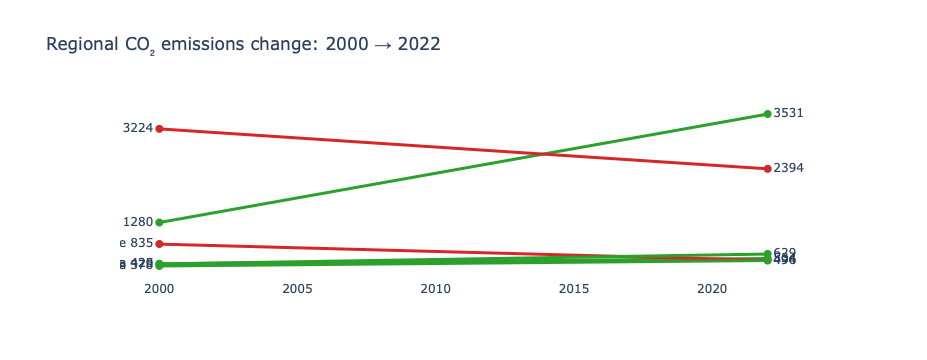

In [4]:
# Task 2 — Slopegraph: regional averages
# YOUR CODE HERE
# Task 2 — Slopegraph: Regional change

regional_avg = df.groupby(['Region','Year'])['CO2_Mt'].mean().reset_index()
slope_df = regional_avg[regional_avg['Year'].isin([2000, 2022])]

fig2 = go.Figure()

for region in slope_df['Region'].unique():
    region_data = slope_df[slope_df['Region'] == region].sort_values('Year')

    val_2000 = region_data[region_data['Year'] == 2000]['CO2_Mt'].values[0]
    val_2022 = region_data[region_data['Year'] == 2022]['CO2_Mt'].values[0]

    # color logic
    color = "#2ca02c" if val_2022 > val_2000 else "#d62728"

    fig2.add_trace(go.Scatter(
        x=[2000, 2022],
        y=[val_2000, val_2022],
        mode='lines+markers+text',
        line=dict(color=color, width=3),
        marker=dict(size=8),
        text=[f"{region} {val_2000:.0f}", f"{val_2022:.0f}"],
        textposition=["middle left", "middle right"],
        showlegend=False
    ))

fig2.update_layout(
    title="Regional CO₂ emissions change: 2000 → 2022",
    plot_bgcolor='white',
    xaxis=dict(showgrid=False, zeroline=False),
    yaxis=dict(showgrid=False, showticklabels=False),
    margin=dict(l=120, r=120)
)

fig2.show()